# ResNet Book Pose Classification

**Goal**: Classify book poses (`book`, `backward`, `flat`, `reverse`) using ResNet18.
**Data**: COCO Format (Detection) -> Converted to Classification via Cropping.
**Author**: AI Assistant

In [1]:
import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import models, transforms
from tqdm.auto import tqdm

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

PyTorch Version: 2.5.1
CUDA Available: True


c:\Users\User\anaconda3\envs\resnet_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Configuration
SEED = 42
BATCH_SIZE = 32
NUM_EPOCHS = 15 
LEARNING_RATE = 0.001
NUM_CLASSES = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Paths
# ROOT_DIR will be the parent of 'resnet_project' since this notebook is inside it
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), '..')) 
DATA_DIR = os.path.join(ROOT_DIR, 'dataset', 'for_resnet', '2.v4-boy3new.coco')
OUTPUT_DIR = os.getcwd() # Should be .../resnet_project

os.makedirs(OUTPUT_DIR, exist_ok=True)

def set_seed(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True

set_seed(SEED)
print(f"Project Root: {ROOT_DIR}")
print(f"Data Dir: {DATA_DIR}")
print(f"Output Dir: {OUTPUT_DIR}")
print(f"Device: {DEVICE}")

Project Root: c:\Users\User\Desktop\中央可憐蟲\大四上\深度學習專案設計\DLPD_finalproject
Data Dir: c:\Users\User\Desktop\中央可憐蟲\大四上\深度學習專案設計\DLPD_finalproject\dataset\for_resnet\2.v4-boy3new.coco
Output Dir: c:\Users\User\Desktop\中央可憐蟲\大四上\深度學習專案設計\DLPD_finalproject\resnet_project
Device: cuda


In [3]:
class CocoCropDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None):
        """
        Args:
            root_dir: Path to the dataset root (containing train, valid, test folders).
            split: 'train', 'valid', or 'test'.
            transform: PyTorch transforms.
        """
        self.root_dir = root_dir
        self.split = split
        self.transform = transform
        self.split_dir = os.path.join(root_dir, split)
        
        # Load COCO JSON
        json_path = os.path.join(self.split_dir, '_annotations.coco.json')
        if not os.path.exists(json_path):
            raise FileNotFoundError(f"JSON not found: {json_path}")
            
        with open(json_path, 'r') as f:
            self.coco_data = json.load(f)
            
        # Map Category IDs to contiguous indices (0-3)
        # Original IDs from dataset analysis: {1: 'backward', 2: 'book', 3: 'flat', 4: 'reverse'}
        # Target: 0, 1, 2, 3
        self.label_map = {1: 0, 2: 1, 3: 2, 4: 3} 
        self.class_names = {0: 'backward', 1: 'book', 2: 'flat', 3: 'reverse'}
        
        # Create list of samples: (image_path, bbox, label)
        self.samples = []
        
        # Create image_id -> filename map
        self.img_id_to_file = {img['id']: img['file_name'] for img in self.coco_data['images']}
        
        # Iterate over annotations
        for ann in self.coco_data['annotations']:
            cat_id = ann['category_id']
            if cat_id not in self.label_map:
                continue 
                
            img_id = ann['image_id']
            if img_id not in self.img_id_to_file:
                continue
                
            file_name = self.img_id_to_file[img_id]
            file_path = os.path.join(self.split_dir, file_name)
            bbox = ann['bbox'] # [x, y, w, h]
            label = self.label_map[cat_id]
            
            self.samples.append({
                'path': file_path,
                'bbox': bbox,
                'label': label
            })
            
        print(f"Loaded {split} set: {len(self.samples)} samples from {len(self.coco_data['images'])} images.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        
        # Load Image
        try:
            image = Image.open(sample['path']).convert('RGB')
        except Exception as e:
            print(f"Error loading {sample['path']}: {e}")
            return self.__getitem__(random.randint(0, len(self.samples)-1))
            
        # Crop Image
        x, y, w, h = sample['bbox']
        left = int(x)
        top = int(y)
        right = int(x + w)
        bottom = int(y + h)
        
        # Safety check for crop coordinates
        width, height = image.size
        left = max(0, left)
        top = max(0, top)
        right = min(width, right)
        bottom = min(height, bottom)
        
        # If invalid crop (e.g. 0 width), take whole image or random crop? 
        # Ideally valid data shouldn't have this, but handling just in case
        if right <= left or bottom <= top:
             crop = image # Fallback
        else:
            crop = image.crop((left, top, right, bottom))
        
        if self.transform:
            crop = self.transform(crop)
            
        return crop, sample['label']

In [4]:
# Define Transforms (ResNet Standard)
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Create Datasets
print("Initializing Datasets...")
train_dataset = CocoCropDataset(DATA_DIR, 'train', data_transforms['train'])
val_dataset = CocoCropDataset(DATA_DIR, 'valid', data_transforms['val'])
test_dataset = CocoCropDataset(DATA_DIR, 'test', data_transforms['val'])

# Dataloaders
# On Windows, num_workers=0 is safer to avoid multiprocessing issues in Notebooks
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

dataloaders = {'train': train_loader, 'val': val_loader}
dataset_sizes = {'train': len(train_dataset), 'val': len(val_dataset)}
class_names = train_dataset.class_names
print(f"Classes: {class_names}")

Initializing Datasets...
Loaded train set: 5302 samples from 5302 images.
Loaded valid set: 223 samples from 223 images.
Loaded test set: 231 samples from 231 images.
Classes: {0: 'backward', 1: 'book', 2: 'flat', 3: 'reverse'}


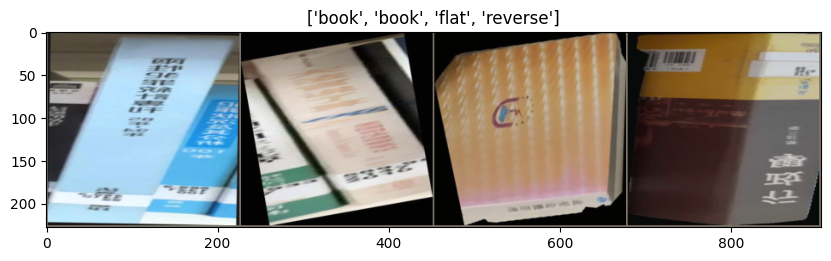

In [5]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)

# Get a batch of training data
inputs, classes = next(iter(train_loader))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs[:4])

plt.figure(figsize=(10, 5))
imshow(out, title=[class_names[x.item()] for x in classes[:4]])

In [6]:
def get_resnet_model(num_classes):
    # Load pretrained ResNet18
    model = models.resnet18(weights='DEFAULT')
    
    # Modify FC layer
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    
    return model

model = get_resnet_model(NUM_CLASSES)
model = model.to(DEVICE)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

print("Model Architecture (Head):")
print(model.fc)

Model Architecture (Head):
Linear(in_features=512, out_features=4, bias=True)


In [7]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    best_model_wts = model.state_dict()
    best_acc = 0.0
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in tqdm(dataloaders[phase], desc=f"{phase} Batch", leave=False):
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward
                # Track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            
            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Deep copy the model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = model.state_dict()
                save_path = os.path.join(OUTPUT_DIR, 'best_resnet.pth')
                torch.save(model.state_dict(), save_path)
                print(f"New best model saved to {save_path} with Acc: {best_acc:.4f}")

        print()

    print(f'Best val Acc: {best_acc:4f}')

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model, history

In [8]:
# Start Training
model, history = train_model(model, criterion, optimizer, exp_lr_scheduler, num_epochs=NUM_EPOCHS)

Epoch 1/15
----------


train Loss: 0.1688 Acc: 0.9447


val Loss: 0.1275 Acc: 0.9596
New best model saved to c:\Users\User\Desktop\中央可憐蟲\大四上\深度學習專案設計\DLPD_finalproject\resnet_project\best_resnet.pth with Acc: 0.9596

Epoch 2/15
----------


train Loss: 0.0732 Acc: 0.9774


val Loss: 0.0585 Acc: 0.9865
New best model saved to c:\Users\User\Desktop\中央可憐蟲\大四上\深度學習專案設計\DLPD_finalproject\resnet_project\best_resnet.pth with Acc: 0.9865

Epoch 3/15
----------


...

val Loss: 0.0560 Acc: 0.9865

Epoch 14/15
----------


train Loss: 0.0081 Acc: 0.9968


val Loss: 0.0627 Acc: 0.9865

Epoch 15/15
----------


train Loss: 0.0071 Acc: 0.9972


val Loss: 0.0592 Acc: 0.9865

Best val Acc: 0.986547


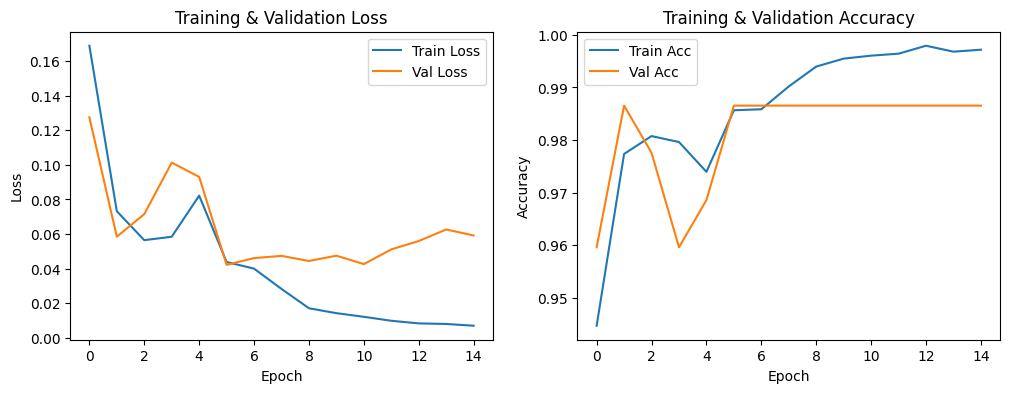

In [9]:
# Plot Results
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Validation Loss')

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training & Validation Accuracy')
plt.show()

In [10]:
# Release GPU Memory after training
import gc
del model
del optimizer
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("GPU Memory Released")


GPU Memory Released


Model variable not found. Reloading best model...


C:\Users\User\AppData\Local\Temp\ipykernel_22848\1728521718.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=DE

Loaded weights from c:\Users\User\Desktop\中央可憐蟲\大四上\深度學習專案設計\DLPD_finalproject\resnet_project\best_resnet.pth


Testing: 100%|██████████| 8/8 [00:02<00:00,  3.55it/s]


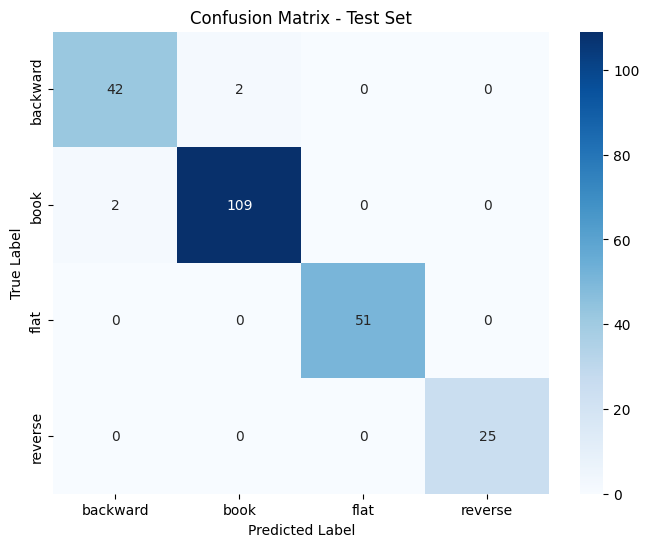

Classification Report:
              precision    recall  f1-score   support

    backward       0.95      0.95      0.95        44
        book       0.98      0.98      0.98       111
        flat       1.00      1.00      1.00        51
     reverse       1.00      1.00      1.00        25

    accuracy                           0.98       231
   macro avg       0.98      0.98      0.98       231
weighted avg       0.98      0.98      0.98       231



In [14]:
# Evaluation on Test Set
import os
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from tqdm.auto import tqdm

# Ensure Model is Loaded
if 'model' not in globals():
    print("Model variable not found. Reloading best model...")
    # Re-define model structure if needed
    if 'get_resnet_model' not in globals():
        from torchvision import models
        import torch.nn as nn
        def get_resnet_model(num_classes):
            model = models.resnet18(weights=None)
            num_ftrs = model.fc.in_features
            model.fc = nn.Linear(num_ftrs, num_classes)
            return model

    model = get_resnet_model(NUM_CLASSES)
    model_path = os.path.join(OUTPUT_DIR, 'best_resnet.pth')
    
    if os.path.exists(model_path):
        model.load_state_dict(torch.load(model_path, map_location=DEVICE))
        print(f"Loaded weights from {model_path}")
    else:
        print(f"Warning: {model_path} not found. Evaluation will be on random weights.")
        
    model = model.to(DEVICE)

def evaluate_model(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Testing"):
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    return np.array(all_labels), np.array(all_preds)

y_true, y_pred = evaluate_model(model, test_loader)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names.values(), 
            yticklabels=class_names.values())
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix - Test Set')
plt.show()

# Classification Report
print("Classification Report:")
target_names = [class_names[i] for i in range(4)]
print(classification_report(y_true, y_pred, target_names=target_names))


ResNet Test Accuracy: 98.27%
Pure CNN Test Accuracy: 96.09%


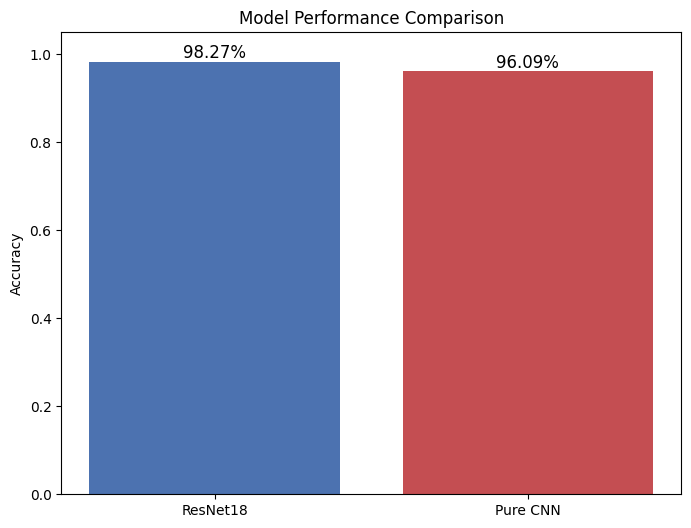

Comparison Note:
- ResNet18 uses Transfer Learning (ImageNet weights) + Fine-tuning.
- Pure CNN is trained from scratch.
- Difference: 2.18% (ResNet - Pure CNN)


In [15]:
# --- Performance Comparison: ResNet vs Pure CNN ---

# ResNet Results (Current Notebook)
# y_true and y_pred are available from the cell above
resnet_acc = np.mean(y_true == y_pred)
print(f"ResNet Test Accuracy: {resnet_acc:.2%}")

# Pure CNN Results (Extracted from pure_cnn/pure_cnn_main.ipynb)
# Based on previous training run (Validation/Test Accuracy)
pure_cnn_acc = 0.9609 # 96.09%
print(f"Pure CNN Test Accuracy: {pure_cnn_acc:.2%}")

# Visualization
models_list = ['ResNet18', 'Pure CNN']
accuracies = [resnet_acc, pure_cnn_acc]

plt.figure(figsize=(8, 6))
bars = plt.bar(models_list, accuracies, color=['#4c72b0', '#c44e52'])

plt.ylim(0, 1.05)
plt.ylabel('Accuracy')
plt.title('Model Performance Comparison')

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2%}',
             ha='center', va='bottom', fontsize=12)

plt.show()

print("Comparison Note:")
print("- ResNet18 uses Transfer Learning (ImageNet weights) + Fine-tuning.")
print("- Pure CNN is trained from scratch.")
print(f"- Difference: {resnet_acc - pure_cnn_acc:.2%} (ResNet - Pure CNN)")


In [ ]:
# --- Part 2: Advanced Improvement - Object Detection (Faster R-CNN) ---
# Goal: Solve the multi-object issue by detecting bounding boxes.
# Model: Faster R-CNN with ResNet50 Backbone.

import os
import torch
import torchvision
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torchvision.transforms as T
from tqdm.auto import tqdm

# --- Robust Path Setup ---
if 'ROOT_DIR' not in globals():
    ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Try to find the correct dataset path
possible_paths = [
    os.path.join(ROOT_DIR, 'dataset', 'for_resnet', '2.v4-boy3new.coco'),
    os.path.join(ROOT_DIR, 'dataset', 'for_resnet', '2.v3i.coco'),
    r"C:\Users\User\Desktop\中央可憐蟲\大四上\深度學習專案設計\DLPD_finalproject\dataset\for_resnet\2.v4-boy3new.coco"
]

DATA_DIR = None
for p in possible_paths:
    if os.path.exists(p):
        DATA_DIR = p
        break

if DATA_DIR is None:
    print(f"Error: Could not find dataset in {possible_paths}")
    # Fallback to current dir if user manually moved it
    DATA_DIR = os.getcwd() 

print(f"Using Detection Data Dir: {DATA_DIR}")

if 'DEVICE' not in globals():
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if 'OUTPUT_DIR' not in globals():
    OUTPUT_DIR = os.getcwd()

# --- Dataset Class (With Box Clipping) ---
class CocoDetectionDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None):
        self.split_dir = os.path.join(root_dir, split)
        self.transform = transform
        
        json_path = os.path.join(self.split_dir, '_annotations.coco.json')
        if not os.path.exists(json_path):
             raise FileNotFoundError(f"JSON not found: {json_path}")
            
        with open(json_path, 'r', encoding='utf-8') as f:
            self.coco = json.load(f)
            
        self.img_map = {img['id']: img for img in self.coco['images']}
        self.ids = list(self.img_map.keys())
        
        # Group annotations
        self.ann_map = {}
        for ann in self.coco['annotations']:
            img_id = ann['image_id']
            if img_id not in self.ann_map:
                self.ann_map[img_id] = []
            self.ann_map[img_id].append(ann)
            
        # Class mapping: {1: 'backward', 2: 'book', 3: 'flat', 4: 'reverse'} -> 1, 2, 3, 4
        self.class_map = {1: 1, 2: 2, 3: 3, 4: 4}

    def __getitem__(self, index):
        img_id = self.ids[index]
        img_info = self.img_map[img_id]
        file_path = os.path.join(self.split_dir, img_info['file_name'])
        
        # Load Image
        image = Image.open(file_path).convert("RGB")
        width, height = image.size
        
        anns = self.ann_map.get(img_id, [])
        boxes = []
        labels = []
        
        for ann in anns:
            cat_id = ann['category_id']
            if cat_id not in self.class_map:
                continue

            x, y, w, h = ann['bbox']
            
            # Clip Boxes to Image Boundaries (Critical Fix)
            x1 = max(0, x)
            y1 = max(0, y)
            x2 = min(width, x + w)
            y2 = min(height, y + h)
            
            # Validate Box
            if x2 <= x1 or y2 <= y1:
                continue # Skip invalid boxes
                
            boxes.append([x1, y1, x2, y2])
            labels.append(self.class_map[cat_id])
            
        # Handle Empty Images
        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
        
        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        target["image_id"] = torch.tensor([img_id])
        
        if self.transform:
            image = self.transform(image)
            
        return image, target

    def __len__(self):
        return len(self.ids)

def collate_fn(batch):
    return tuple(zip(*batch))

# --- Training Setup ---
try:
    print("Setting up Detection Data...")
    det_transform = T.Compose([T.ToTensor()])

    det_train_dataset = CocoDetectionDataset(DATA_DIR, 'train', det_transform)
    # Reduce Batch Size to 2 to prevent OOM
    det_train_loader = DataLoader(det_train_dataset, batch_size=2, shuffle=True, collate_fn=collate_fn, num_workers=0)

    print("Loading Faster R-CNN (ResNet50)...")
    det_model = fasterrcnn_resnet50_fpn(weights='DEFAULT')
    in_features = det_model.roi_heads.box_predictor.cls_score.in_features
    det_model.roi_heads.box_predictor = FastRCNNPredictor(in_features, 5) # 4 classes + background

    det_model.to(DEVICE)
    params = [p for p in det_model.parameters() if p.requires_grad]
    det_optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

    print("Starting Detection Training (3 Epochs demo)...")
    DET_EPOCHS = 3

    for epoch in range(DET_EPOCHS):
        det_model.train()
        running_loss = 0.0
        
        pbar = tqdm(det_train_loader, desc=f"Epoch {epoch+1}")
        for images, targets in pbar:
            images = [image.to(DEVICE) for image in images]
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
            
            loss_dict = det_model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            
            det_optimizer.zero_grad()
            losses.backward()
            det_optimizer.step()
            
            running_loss += losses.item()
            pbar.set_postfix({'loss': losses.item()})
            
        avg_loss = running_loss / len(det_train_loader)
        print(f"Epoch {epoch+1} Average Loss: {avg_loss:.4f}")

    save_path = os.path.join(OUTPUT_DIR, 'fasterrcnn_resnet50.pth')
    torch.save(det_model.state_dict(), save_path)
    print(f"Detection Model saved to {save_path}")
    
    # Cleanup
    torch.cuda.empty_cache()

except Exception as e:
    print(f"CRITICAL ERROR: {e}")
    import traceback
    traceback.print_exc()


Using Detection Data Dir: c:\Users\User\Desktop\中央可憐蟲\大四上\深度學習專案設計\DLPD_finalproject\dataset\for_resnet\2.v4-boy3new.coco
Setting up Detection Data...
Loading Faster R-CNN (ResNet50)...


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to C:\Users\User/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:14<00:00, 11.4MB/s] 


Starting Detection Training (3 Epochs demo)...


Epoch 1: 100%|██████████| 2651/2651 [15:42<00:00,  2.81it/s, loss=0.0149] 


Epoch 1 Average Loss: 0.0344


Epoch 2: 100%|██████████| 2651/2651 [16:39<00:00,  2.65it/s, loss=0.00935]


Epoch 2 Average Loss: 0.0160


Epoch 3:  81%|████████▏ | 2157/2651 [14:49<02:49,  2.91it/s, loss=0.0118]  